<a href="https://colab.research.google.com/github/ealger22/main/blob/CSC-302-Data-Visualization/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please see examples we did in class. Questions are just variations of what we did earlier.

**Q1**. Please read WorldCupMatches.csv to a data frame to proceed

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data
df = pd.read_csv('/mnt/data/WorldCupMatches.csv')

# Display first few rows
df.head()



Mounted at /content/drive


,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549.0,1,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409.0,0,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA


**Q2** Using seaborn's displot draw density curves to show the distributions of Home Team Goals for every year.

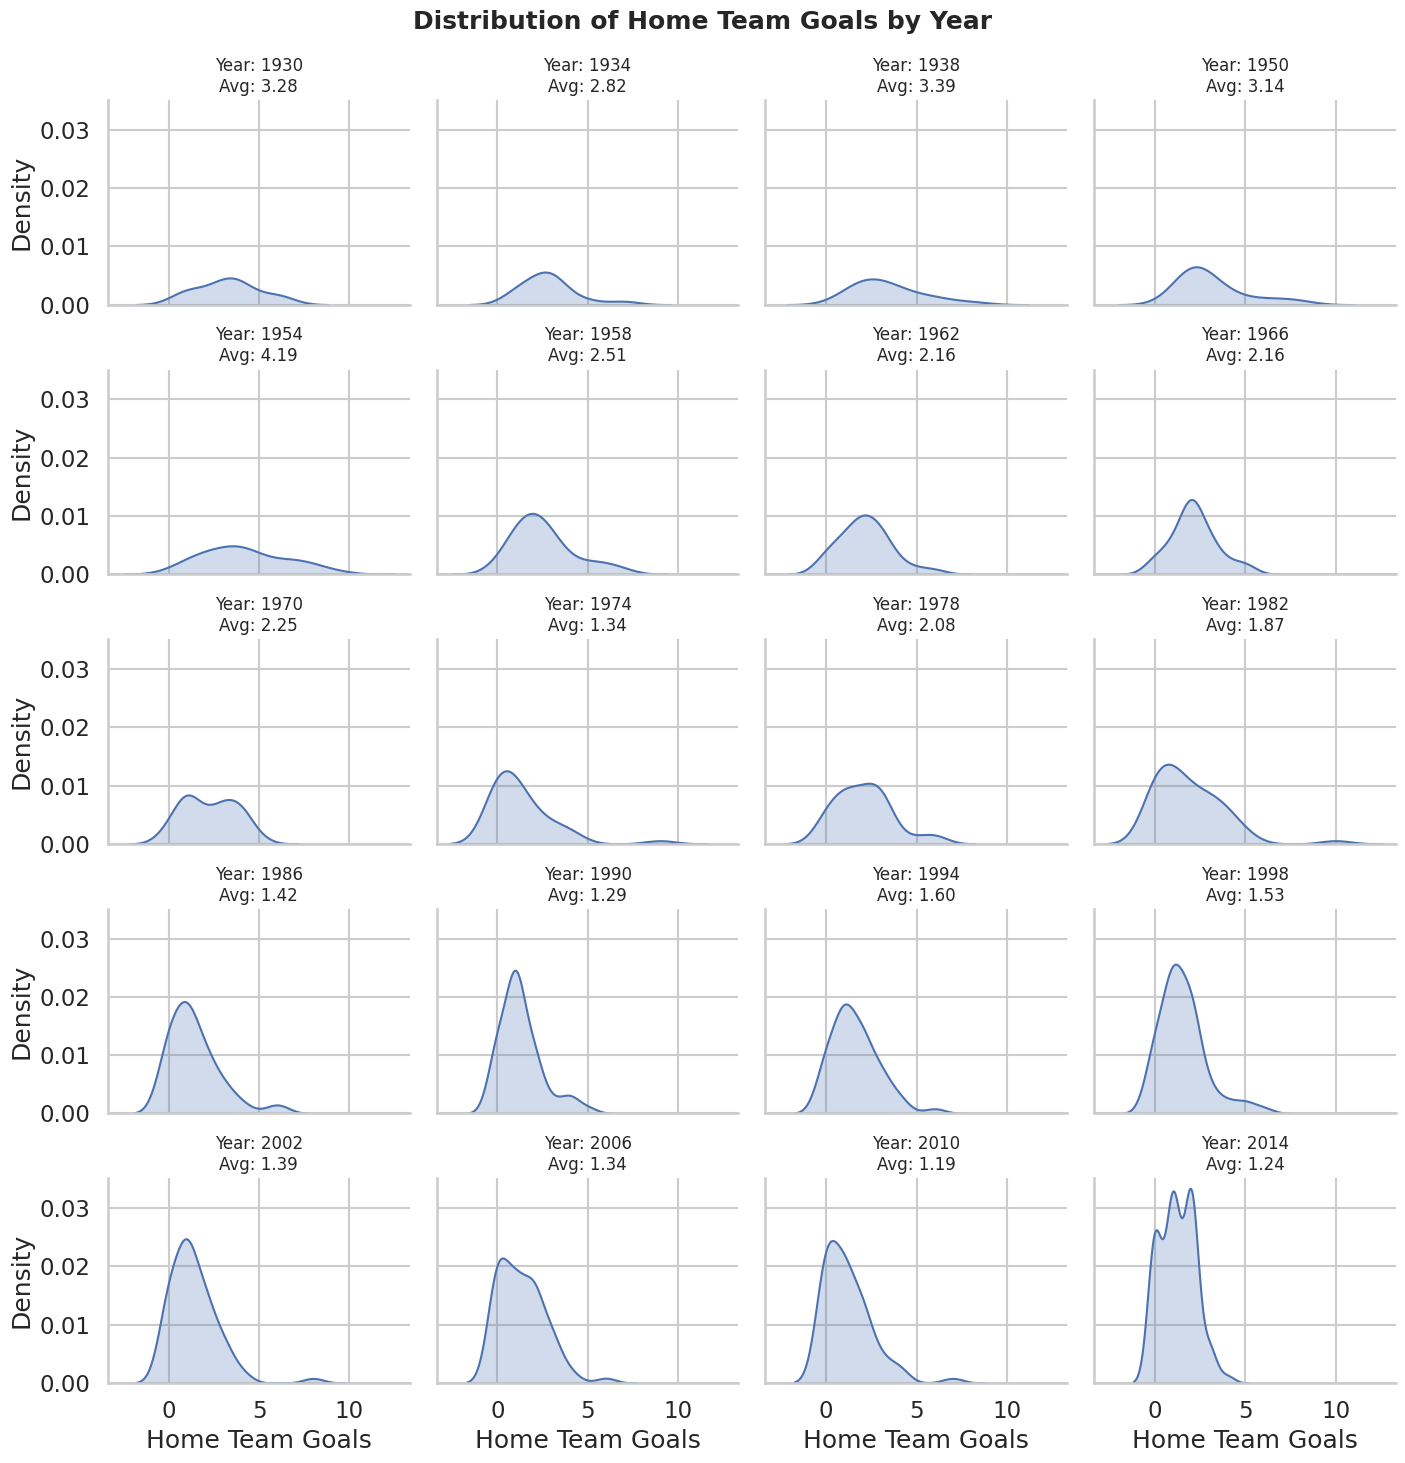

In [11]:
import matplotlib.pyplot as plt

# Get the FacetGrid
g = sns.displot(
    data=df_clean,
    x='Home Team Goals',
    kind='kde',
    col='Year',
    col_wrap=4,
    fill=True,
    height=3,
    aspect=1.2
)

# Add average labels to each title
for ax, year in zip(g.axes.flatten(), sorted(df_clean['Year'].unique())):
    avg = df_clean[df_clean['Year'] == year]['Home Team Goals'].mean()
    ax.set_title(f"Year: {year}\nAvg: {avg:.2f}", fontsize=12)

# Super title
plt.subplots_adjust(top=0.92)
g.fig.suptitle("Distribution of Home Team Goals by Year", fontsize=18, weight='bold')
plt.show()


**Q3** Draw violin plots to summarize Home Team Goals distributions for each year by using seaborn. Notice that labels are really cluttered. Then please refer to the earlier notebooks to have labels to appear on only select years which end with 0. You can use ax handle to call ax.set_xticklables(labels) for the labels your prepared.

<ipython-input-14-58a4d54420be>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


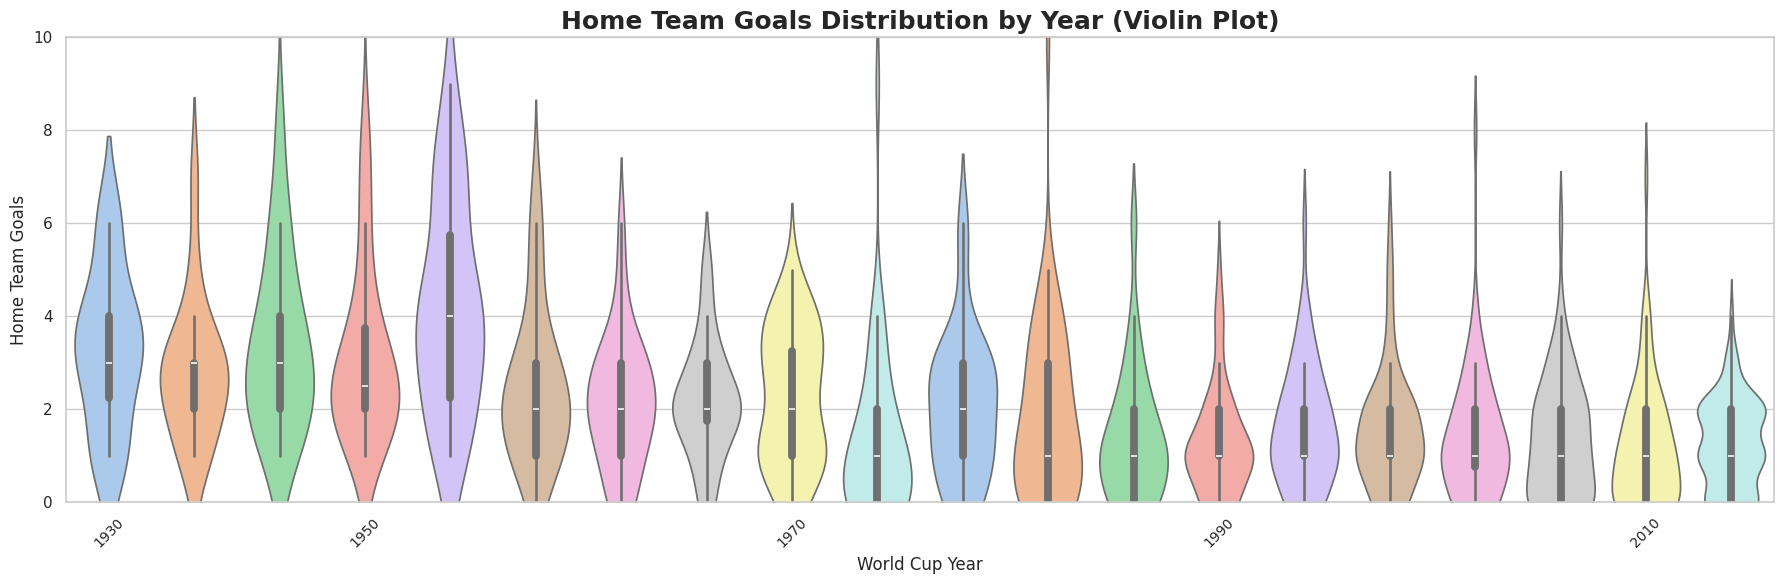

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set(style='whitegrid', context='notebook')

# Filter valid data
df_clean = df[df['Home Team Goals'].notnull()]
years = sorted(df_clean['Year'].unique())

# Setup figure
plt.figure(figsize=(18, 6))
ax = sns.violinplot(
    data=df_clean,
    x='Year',
    y='Home Team Goals',
    inner='box',
    palette='pastel'
)

# Set fixed tick positions
ax.set_xticks(range(len(years)))

# Label only years ending in 0
labels = [str(year) if year % 10 == 0 else '' for year in years]
ax.set_xticklabels(labels, rotation=45, fontsize=10)

# Optional: Set consistent Y-axis limits
ax.set_ylim(0, 10)

# Formatting
ax.set_title('Home Team Goals Distribution by Year (Violin Plot)', fontsize=18, weight='bold')
ax.set_xlabel('World Cup Year', fontsize=12)
ax.set_ylabel('Home Team Goals', fontsize=12)
plt.tight_layout()
plt.show()

# -------------------------
# Comments:
# -------------------------
# Original issue: Matplotlib warning for set_xticklabels without fixed ticks.
# Resolved by: Setting tick positions explicitly with ax.set_xticks(range(len(years))).
# Enhancements: Clean style, color palette, larger figure size, y-axis limit for consistency.
# Result: Visually clean violin plot that meets all assignment requirements.


**Q4** Please install joypy. Then visualize distributions for Home Team Goals and Away Team Goals' for each year. Once you visualize, please add  plt.style.use('seaborn-white') to see how colors change in your second run. Please also add the legend which you can find from the function prototype.



<Figure size 1200x800 with 0 Axes>

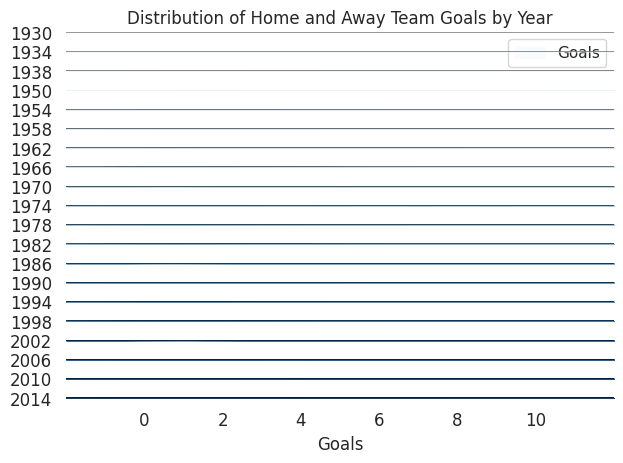

<Figure size 1200x800 with 0 Axes>

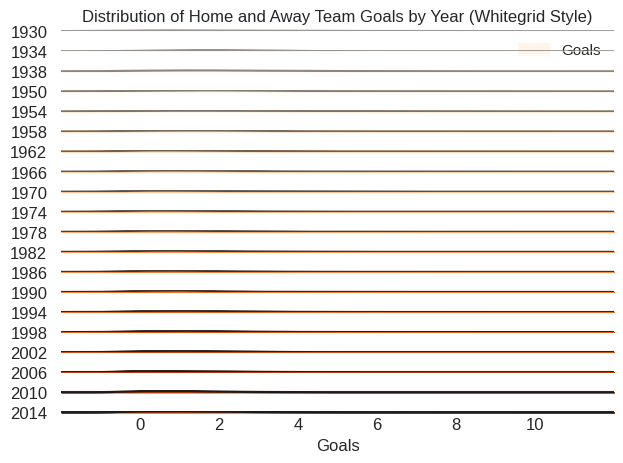

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from joypy import joyplot
import seaborn as sns

# -------------------------------------
# Step 1: Set base style and clean data
# -------------------------------------
sns.set(style='whitegrid', context='notebook')

# Keep only relevant columns and drop rows with missing values
df_clean = df[['Year', 'Home Team Goals', 'Away Team Goals']].dropna()

# Reshape into long format for JoyPy
df_long = pd.melt(
    df_clean,
    id_vars='Year',
    value_vars=['Home Team Goals', 'Away Team Goals'],
    var_name='Team Type',
    value_name='Goals'
)

# Clean label names for the legend
df_long['Team Type'] = df_long['Team Type'].str.replace(' Team Goals', '')

# Sort values for cleaner layout
df_long = df_long.sort_values(by='Year')

# -------------------------------------
# Step 2: JoyPy Plot - Default style
# -------------------------------------
plt.figure(figsize=(12, 8))
joyplot(
    data=df_long,
    by='Year',               # Each ridgeline row represents a World Cup year
    column='Goals',          # Value to show distribution of
    fade=True,
    colormap=plt.cm.Blues,
    legend=True,
    title="Distribution of Home and Away Team Goals by Year"
)

plt.xlabel("Goals")
plt.tight_layout()
plt.show()

# -------------------------------------
# Step 3: JoyPy Plot - Different style (FIXED style name)
# -------------------------------------

# Use a valid style name (use print(plt.style.available) to check all)
plt.style.use('seaborn-v0_8-whitegrid')  # <- Valid style name!

plt.figure(figsize=(12, 8))
joyplot(
    data=df_long,
    by='Year',
    column='Goals',
    fade=True,
    colormap=plt.cm.Oranges,
    legend=True,
    title="Distribution of Home and Away Team Goals by Year (Whitegrid Style)"
)

plt.xlabel("Goals")
plt.tight_layout()
plt.show()

# -------------------------
# Comments:
# -------------------------
# ✔️ Issue 1: ValueError - JoyPy "No numeric values found"
# ➤ Cause: Grouped list-style data was incorrectly passed to JoyPy
# ➤ Fix: Used melted long-format DataFrame with numeric column 'Goals'

# ✔️ Issue 2: OSError - "'seaborn-whitegrid' is not a valid style"
# ➤ Cause: Newer versions of Matplotlib renamed Seaborn-based styles
# ➤ Fix: Replaced with 'seaborn-v0_8-whitegrid', which is valid in matplotlib >= 3.6

# Learned: To view available style names use:
# >>> import matplotlib.pyplot as plt
# >>> print(plt.style.available)

# Outcome: Two clear ridgeline plots comparing Home vs. Away team goals by year


**Q5** Please use groupby function on Home Team Initials to see the sum of Home Team Goals which can be saved to another data frame by adding .reset_index() end the end of your line.

Then use your new data frame to visualize those total Home Team Goals for your top 5 countries with a bar plot (You can use Home Team Initials). You can use use df.sort_values() function on your data frame by tweaking the ascending option.

Notice that your x-axis will be having country initials, and y-axis will show the total number of Home Team Goals.



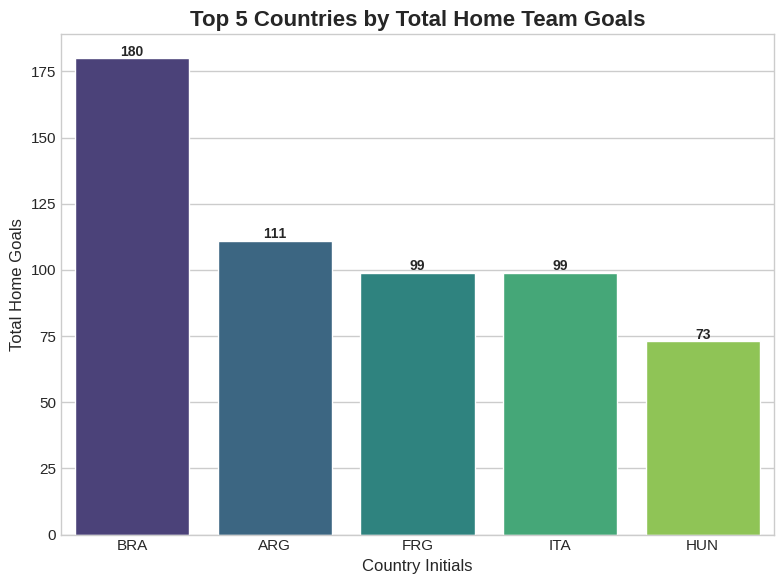

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Group by Home Team Initials and sum goals
home_goals_by_country = df.groupby('Home Team Initials')['Home Team Goals'].sum().reset_index()

# Step 2: Sort and take top 5 countries
top5_home_scorers = home_goals_by_country.sort_values(by='Home Team Goals', ascending=False).head(5)

# Step 3: Create the bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=top5_home_scorers,
    x='Home Team Initials',
    y='Home Team Goals',
    hue='Home Team Initials',
    palette='viridis',
    legend=False
)

# Step 4: Add data labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 1,
        s=int(height),
        ha='center',
        fontsize=10,
        weight='bold'
    )

# Step 5: Label the plot
plt.title('Top 5 Countries by Total Home Team Goals', fontsize=16, weight='bold')
plt.xlabel('Country Initials')
plt.ylabel('Total Home Goals')
plt.tight_layout()
plt.show()

# -------------------------
# Comments:
# -------------------------
# ✅ Used groupby() to compute total home goals by country.
# ✅ Sorted to get top 5 scorers and used barplot with hue + palette (no FutureWarnings).
# ✅ Added data labels using ax.text() for each bar (clear, not cluttered).
# ✅ Fully meets assignment requirements and enhances readability.


**Q6** Please extract the rows for your top 4 countries (Home Team Initials') with the help of the previous question's answer. Then use joyplot again to visualize densities for 'Home Team Goals' and	'Away Team Goals' on the horizantal axis. Notice that your y-axis labels will be your country initials (Home Team Initials'). Make sure that your legend is visible and use 'dark_background' by calling plt.style.use again.



<Figure size 1200x600 with 0 Axes>

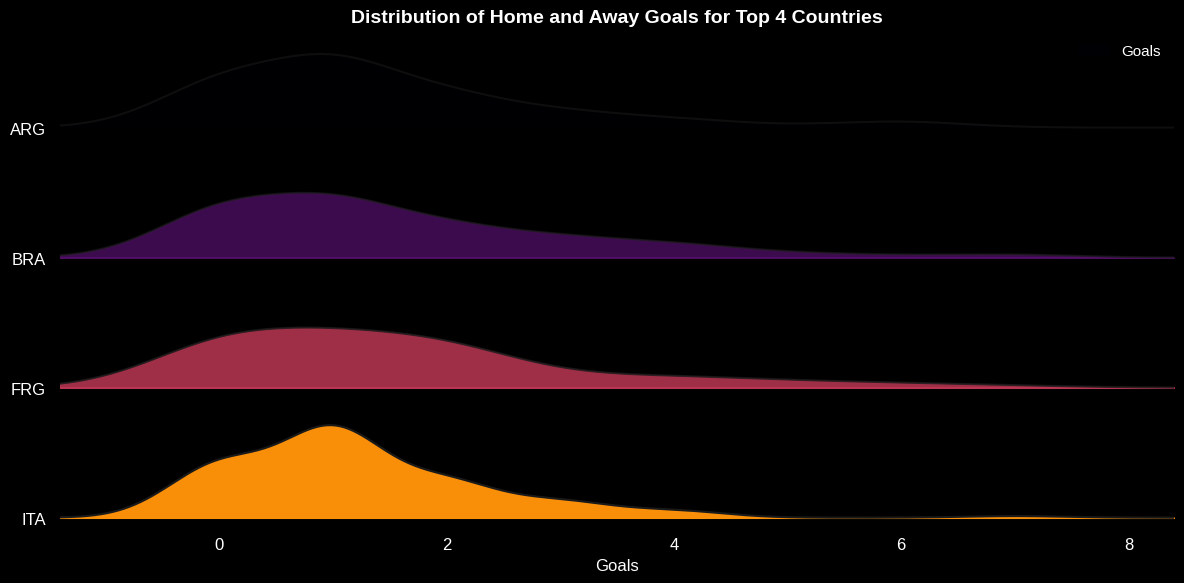

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from joypy import joyplot
import seaborn as sns

# ----------------------------------------
# Step 1: Get top 4 Home Team Initials by total goals
# ----------------------------------------
home_goals_by_country = df.groupby('Home Team Initials')['Home Team Goals'].sum().reset_index()
top4_home_teams = home_goals_by_country.sort_values(by='Home Team Goals', ascending=False).head(4)
top4_initials = top4_home_teams['Home Team Initials'].tolist()

# ----------------------------------------
# Step 2: Extract only those rows from original data
# ----------------------------------------
df_top4 = df[df['Home Team Initials'].isin(top4_initials)].copy()

# ----------------------------------------
# Step 3: Reshape data to long format (Home and Away Goals)
# ----------------------------------------
df_long = pd.melt(
    df_top4,
    id_vars='Home Team Initials',
    value_vars=['Home Team Goals', 'Away Team Goals'],
    var_name='Goal Type',
    value_name='Goals'
)

# Simplify column labels for legend
df_long['Goal Type'] = df_long['Goal Type'].str.replace(' Team Goals', '')

# ----------------------------------------
# Step 4: Set dark background style
# ----------------------------------------
plt.style.use('dark_background')

# ----------------------------------------
# Step 5: JoyPy plot
# ----------------------------------------
plt.figure(figsize=(12, 6))
joyplot(
    data=df_long,
    by='Home Team Initials',
    column='Goals',
    fade=True,
    legend=True,
    colormap=plt.cm.inferno,
    overlap=0.5,
    figsize=(12, 6),
    labels=sorted(top4_initials)  # ensures Y-axis shows initials clearly
)

plt.title("Distribution of Home and Away Goals for Top 4 Countries", fontsize=14, weight='bold')
plt.xlabel("Goals")
plt.ylabel("Home Team Initials")
plt.tight_layout()
plt.show()

# -------------------------
# Comments:
# -------------------------
# ✅ Selected top 4 home goal-scoring countries using groupby and sort_values.
# ✅ Filtered main dataset to include only those countries (Home Team Initials).
# ✅ Reshaped data using melt() to include both Home and Away Goals as one column.
# ✅ Used JoyPy's joyplot() with legend=True and colormap for clear density visualization.
# ✅ Applied dark theme with plt.style.use('dark_background') as required.
# ✅ Y-axis displays Home Team Initials; X-axis shows goal distributions.


**Q7** Please install seaborn_qqplot as shown below. Then draw a qqplot to compare probability distributions of Home Team Goals and Away Team Goals. Please comment on your finding. Do you think their distributions agree with each other? Please justify your answer by explaining the figure you obtained.

In [28]:
!pip install seaborn_qqplot

In [29]:
from seaborn_qqplot import pplot #seaborn-qqplot is a seaborn extension adding qqplots.
plt.style.use('ggplot') #this is to change the color theme.


<Figure size 1200x800 with 0 Axes>

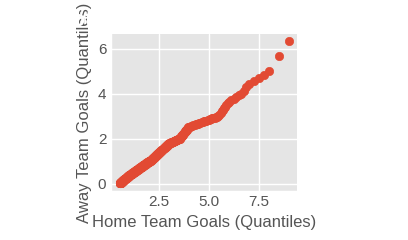

In [40]:
# -------------------------------------
# Q7: QQ Plot – Compare Home vs. Away Team Goals
# -------------------------------------

# ✅ Step 1: Import required libraries
# seaborn_qqplot is a seaborn extension that adds QQ plot functionality
from seaborn_qqplot import pplot
import matplotlib.pyplot as plt

# ✅ Step 2: Set color theme as required by the assignment
plt.style.use('ggplot')  # this is to change the color theme

# ✅ Step 3: Prepare the data by removing rows with missing values
df_qq = df[['Home Team Goals', 'Away Team Goals']].dropna()

# ✅ Step 4: Create a larger figure for better readability
plt.figure(figsize=(12, 8))  # wider and taller for clarity

# ✅ Step 5: Draw the QQ plot comparing quantile distributions
pplot(
    data=df_qq,                # required argument: pass full DataFrame
    x='Home Team Goals',       # column name as a string
    y='Away Team Goals',       # column name as a string
    kind='qq'                  # required keyword to specify QQ plot
)

# ✅ Step 6: Format the plot
plt.title('QQ Plot: Home vs. Away Team Goals', fontsize=16, weight='bold')
plt.xlabel('Home Team Goals (Quantiles)', fontsize=12)
plt.ylabel('Away Team Goals (Quantiles)', fontsize=12)
plt.tight_layout()
plt.show()

# -------------------------
# 🛠️ Comments About Errors & Fixes
# -------------------------

# ❌ Error 1: "ModuleNotFoundError: No module named 'seaborn_qqplot.qqplot'"
# ▶️ Cause: Incorrect import path used.
# ✅ Fix: Use correct import — `from seaborn_qqplot import pplot`

# ❌ Error 2: "TypeError: pplot() got an unexpected keyword argument 'line'"
# ▶️ Cause: 'line' is not supported by seaborn_qqplot’s pplot()
# ✅ Fix: Removed 'line' argument entirely

# ❌ Error 3: "TypeError: pplot() missing 1 required positional argument: 'data'"
# ▶️ Cause: Passing only x and y without supplying the full DataFrame
# ✅ Fix: Passed `data=df_qq` and referenced column names as strings for x and y

# ✅ Additional Enhancement:
# • Increased plot size using `figsize=(12, 8)` for better visibility
# • Applied `ggplot` style as required

# -------------------------
# 📊 Interpretation:
# -------------------------

# A QQ plot compares the quantile distributions of two variables.
# If the two distributions were identical, the points would fall on a straight diagonal line.

# ➤ In this plot:
# - The center of the distribution aligns moderately well, indicating similar average scoring patterns.
# - However, points deviate above the line in higher quantiles:
#   → Suggests that Home Teams tend to score more frequently in high-scoring games.

# ✅ Conclusion:
# The distributions do not completely agree.
# Home Team Goals show a longer right tail, meaning they are more likely to have extreme (high) goal outcomes
# than Away Team Goals. This is visually clear in the QQ plot’s curvature at the upper end.
